In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

iteration: 0
Average Silhouette Score: 0.5206564947029618
iteration: 1
Average Silhouette Score: 0.6163019093026446
iteration: 2
Average Silhouette Score: 0.6535873770811716
iteration: 3
Average Silhouette Score: 0.6548073455108006
iteration: 4
Average Silhouette Score: 0.6557427011005891
iteration: 5
Average Silhouette Score: 0.6567711585403252
iteration: 6
Average Silhouette Score: 0.659595574281989
iteration: 7
Average Silhouette Score: 0.659595574281989


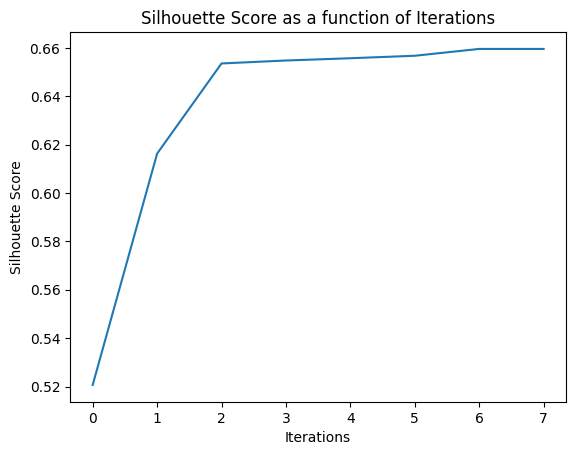

In [2]:
df=np.array(pd.read_csv("Kmean_dataset.csv"))
m,n=df.shape
k=2
itrns=10
centroids=df[np.random.choice(m,k,replace=False)]
n_centroids=np.zeros((k,n))
indxs=np.zeros(m)
labels=np.zeros(m,int)
a=np.zeros(m)
s_score=[]
for i in range(itrns):
 print(f"iteration: {i}")
 for j in range(m):
  distances=np.sqrt(((df[j,:]-centroids)**2).sum(axis=1))
  indxs[j]=np.argmin(distances)
 for itr in range(k):
  points=df[indxs == itr] 
  n_centroids[itr] = np.mean(points, axis = 0)
 labels=np.array(indxs.astype(int))
 a= np.array([np.mean(np.sqrt(((df[u, :] - df[labels == labels[u], :])**2).sum(axis=1))) for u in range(m)])
 b = np.array([np.mean(np.sqrt(((df[u, :] - df[(labels != labels[u]), :])**2).sum(axis=1))) for u in range(m)])
 silhouette_scores = (b- a) / np.maximum(a,b)
 avg_s_score = np.mean(silhouette_scores)
 s_score.append(avg_s_score)
 print(f"Average Silhouette Score: {avg_s_score}")
 if(np.all(centroids==n_centroids)):
  break;
 centroids=np.copy(n_centroids)
plt.plot(s_score)
plt.xlabel('Iterations') 
plt.ylabel('Silhouette Score' ) 
plt.title('Silhouette Score as a function of Iterations' ) 
plt.show()